# **Bag of Visual Words(BoVW) for Image Classification**

### **Libraries**

In [1]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.cluster import MiniBatchKMeans
from collections import defaultdict
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from pathlib import Path
from glob import glob
from tqdm import tqdm
import pandas as pd
import numpy as np
import importlib
import argparse
import joblib
import random
import time
import math
import cv2 
import os

### **Configuration**

In [2]:
glob = importlib.import_module("glob")
DATASET_DIR = "/kaggle/input/ucmerced-landuse-dataset/UCMerced_LandUse"
RESULTS_DIR = "results"
CACHE_DIR = "cache"
DESCRIPTOR_SAMPLE_LIMIT = 100000  # sample descriptors for KMeans (reduce memory)
SIFT_MAX_FEATURES = 0  # 0 => all detected features
RANDOM_STATE = 42
N_JOBS = -1  # for scikit-learn where supported
conf_dir = os.path.join(RESULTS_DIR, "confusion")
conf_paths = sorted(glob.glob(os.path.join(conf_dir, "confusion_*.png")))

### **Experiments**

In [3]:
SPLITS = [(0.8, 0.2), (0.7, 0.3), (0.6, 0.4), (0.5, 0.5)]
K_LIST = [21, 50, 100, 150, 200, 250, 300]
N_REPEAT = 1 
NORMALIZATION = "l1"  # "l1" or "l2"

In [4]:
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, "plots"), exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, "confusion"), exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

In [5]:
def get_image_paths_and_labels(root):
    classes = sorted([d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))])
    paths, labels = [], []
    for cls in classes:
        imgs = sorted(glob.glob(os.path.join(root, cls, "*.tif")))
        for p in imgs:
            paths.append(p)
            labels.append(cls)
    return np.array(paths), np.array(labels), classes

In [6]:
def make_sift():
    # Try modern API, fallback to xfeatures2d if necessary
    try:
        sift = cv2.SIFT_create(nfeatures=SIFT_MAX_FEATURES)
        return sift
    except AttributeError:
        try:
            sift = cv2.xfeatures2d.SIFT_create()
            return sift
        except Exception as e:
            raise RuntimeError("SIFT not available. Install opencv-contrib-python.") from e

In [7]:
SIFT = make_sift()

In [8]:
def extract_sift_descriptors(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise RuntimeError(f"failed to read {image_path}")
    kp, des = SIFT.detectAndCompute(img, None)
    return des

In [9]:
def cache_descriptors(image_paths, cache_file):
    if os.path.exists(cache_file):
        cache = joblib.load(cache_file)
        if set(cache.keys()) == set(image_paths):
            return cache
    cache = {}
    print("extracting SIFT descriptors (will cache) ...")
    for p in tqdm(image_paths):
        des = extract_sift_descriptors(p)
        cache[p] = des
    joblib.dump(cache, cache_file, compress=3)
    return cache # image_path -> descriptors

In [10]:
def collect_training_descriptors(train_paths, cache, sample_limit=DESCRIPTOR_SAMPLE_LIMIT):
    all_desc = []
    for p in train_paths:
        des = cache.get(p)
        if des is None:
            continue
        all_desc.append(des)
    if len(all_desc) == 0:
        return np.zeros((0,128), dtype=np.float32)
    all_desc = np.vstack(all_desc)
    n = all_desc.shape[0]
    if n > sample_limit:
        idx = np.random.choice(n, size=sample_limit, replace=False)
        all_desc = all_desc[idx]
    return all_desc

In [11]:
def build_vocabulary(descriptors_sampled, k):
    print(f"clustering {len(descriptors_sampled)} descriptors -> K={k} (MiniBatchKMeans)")
    mbk = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, batch_size=4096)
    mbk.fit(descriptors_sampled)
    return mbk

In [12]:
def compute_histogram_for_image(descriptors, kmeans):
    k = kmeans.n_clusters
    if descriptors is None or descriptors.shape[0] == 0:
        return np.zeros(k, dtype=np.float32)
    words = kmeans.predict(descriptors)
    hist = np.bincount(words, minlength=k).astype(np.float32)
    return hist

In [13]:
def normalize_histograms(hists, norm=NORMALIZATION):
    if norm == "l1":
        return normalize(hists, norm='l1', axis=1)
    elif norm == "l2":
        return normalize(hists, norm='l2', axis=1)
    else:
        raise ValueError("norm must be 'l1' or 'l2'")

In [14]:
def run_experiment(train_paths, test_paths, train_labels, test_labels, cache, k, norm=NORMALIZATION):
    # build vocabulary from training descriptors
    t0 = time.perf_counter()
    desc_sample = collect_training_descriptors(train_paths, cache)
    t_desc_sample = time.perf_counter()
    if desc_sample.shape[0] == 0:
        raise RuntimeError("No descriptors found in training set.")
    kmeans = build_vocabulary(desc_sample, k)
    t_kmeans = time.perf_counter()

    # compute histograms for train and test
    X_train = []
    for p in train_paths:
        hist = compute_histogram_for_image(cache.get(p), kmeans)
        X_train.append(hist)
    X_train = np.vstack(X_train)
    X_train = normalize_histograms(X_train, norm=norm)

    X_test = []
    for p in test_paths:
        hist = compute_histogram_for_image(cache.get(p), kmeans)
        X_test.append(hist)
    X_test = np.vstack(X_test)
    X_test = normalize_histograms(X_test, norm=norm)

    t_hist = time.perf_counter()

    # train SVM
    clf = SVC(kernel='linear', random_state=RANDOM_STATE)
    t0_train = time.perf_counter()
    clf.fit(X_train, train_labels)
    t_train_end = time.perf_counter()

    # predict
    t0_pred = time.perf_counter()
    y_pred = clf.predict(X_test)
    t_pred_end = time.perf_counter()

    acc = accuracy_score(test_labels, y_pred)
    cm = confusion_matrix(test_labels, y_pred, labels=np.unique(train_labels))

    times = {
        "descriptors_sampling_s": t_desc_sample - t0,
        "kmeans_s": t_kmeans - t_desc_sample,
        "build_histograms_s": t_hist - t_kmeans,
        "train_s": t_train_end - t0_train,
        "predict_s": t_pred_end - t0_pred,
        "total_s": t_pred_end - t0
    }

    return {
        "clf": clf,
        "kmeans": kmeans,
        "accuracy": acc,
        "confusion_matrix": cm,
        "times": times,
        "y_pred": y_pred,
        "X_test": X_test
    }

In [15]:
def plot_confusion(cm, labels, out_path, title=None):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(10,10))
    disp.plot(ax=ax, xticks_rotation=90, cmap=plt.cm.Blues, colorbar=False)
    if title:
        plt.title(title)
    plt.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.close(fig)

In [16]:
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

In [17]:
print("loading dataset...")
image_paths, image_labels, classes = get_image_paths_and_labels(DATASET_DIR)
print(f"found {len(classes)} classes, {len(image_paths)} images.")

loading dataset...
found 21 classes, 2100 images.


In [18]:
# build cache file name based on dataset dir
cache_file = os.path.join(CACHE_DIR, f"descriptors_{Path(DATASET_DIR).name}.joblib")
cache = cache_descriptors(image_paths, cache_file)

results = []
idx = np.arange(len(image_paths))

extracting SIFT descriptors (will cache) ...


100%|██████████| 2100/2100 [01:09<00:00, 30.28it/s]


In [19]:
total_experiments = len(SPLITS) * len(K_LIST) * N_REPEAT
exp_counter = 0

In [20]:
for split_idx, split in enumerate(SPLITS, start=1):
    train_frac = split[0]
    test_frac = split[1]

    print(f"\n=== [split {split_idx}/{len(SPLITS)}] train={train_frac:.2f}, test={test_frac:.2f} ===")
    train_paths, test_paths, train_labels, test_labels = train_test_split(
        image_paths, image_labels, train_size=train_frac, test_size=test_frac,
        stratify=image_labels, random_state=RANDOM_STATE
    )
    print(f"data prepared → {len(train_paths)} train / {len(test_paths)} test images.")

    # tqdm to show global experiment progress
    for k_idx, k in enumerate(K_LIST, start=1):
        for rep in range(N_REPEAT):
            exp_counter += 1
            print(f"\n--- [experiment {exp_counter}/{total_experiments}] split {int(train_frac*100)}-{int(test_frac*100)} | "
                  f"k={k} | rep={rep} ---")

            try:
                print("step 1: building vocabulary and extracting histograms ...")
                res = run_experiment(train_paths, test_paths, train_labels, test_labels,
                                     cache, k, norm=NORMALIZATION)

                print("step 2: senerating confusion matrix plot ...")
                cm_labels = np.unique(train_labels)
                cm_path = os.path.join(
                    RESULTS_DIR, "confusion",
                    f"confusion_{int(train_frac*100)}_{k}_rep{rep}.png"
                )
                plot_confusion(res["confusion_matrix"], cm_labels, cm_path,
                               title=f"Split {int(train_frac*100)}-{int(test_frac*100)} K={k}")

                print("step 3: saving intermediate results ...")
                results.append({
                    "train_frac": train_frac,
                    "test_frac": test_frac,
                    "k": k,
                    "rep": rep,
                    "accuracy": res["accuracy"],
                    **res["times"]
                })
                df = pd.DataFrame(results)
                df.to_csv(os.path.join(RESULTS_DIR, "summary.csv"), index=False)

                print(f"done: split {int(train_frac*100)}-{int(test_frac*100)}, k={k}, accuracy={res['accuracy']:.3f}")
                print(f"total time: {res['times']['total_s']:.1f}s\n")

            except Exception as e:
                print(f"experiment failed for split={train_frac}, k={k}, rep={rep}: {e}")
                continue


=== [split 1/4] train=0.80, test=0.20 ===
data prepared → 1680 train / 420 test images.

--- [experiment 1/28] split 80-20 | k=21 | rep=0 ---
step 1: building vocabulary and extracting histograms ...
clustering 100000 descriptors -> K=21 (MiniBatchKMeans)


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


step 2: senerating confusion matrix plot ...
step 3: saving intermediate results ...
done: split 80-20, k=21, accuracy=0.412
total time: 2.0s


--- [experiment 2/28] split 80-20 | k=50 | rep=0 ---
step 1: building vocabulary and extracting histograms ...
clustering 100000 descriptors -> K=50 (MiniBatchKMeans)


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


step 2: senerating confusion matrix plot ...
step 3: saving intermediate results ...
done: split 80-20, k=50, accuracy=0.400
total time: 2.4s


--- [experiment 3/28] split 80-20 | k=100 | rep=0 ---
step 1: building vocabulary and extracting histograms ...
clustering 100000 descriptors -> K=100 (MiniBatchKMeans)


...

step 2: senerating confusion matrix plot ...
step 3: saving intermediate results ...
done: split 50-50, k=200, accuracy=0.365
total time: 5.7s


--- [experiment 27/28] split 50-50 | k=250 | rep=0 ---
step 1: building vocabulary and extracting histograms ...
clustering 100000 descriptors -> K=250 (MiniBatchKMeans)


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


step 2: senerating confusion matrix plot ...
step 3: saving intermediate results ...
done: split 50-50, k=250, accuracy=0.346
total time: 6.7s


--- [experiment 28/28] split 50-50 | k=300 | rep=0 ---
step 1: building vocabulary and extracting histograms ...
clustering 100000 descriptors -> K=300 (MiniBatchKMeans)


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


step 2: senerating confusion matrix plot ...
step 3: saving intermediate results ...
done: split 50-50, k=300, accuracy=0.336
total time: 8.2s



In [21]:
# summary plotting: accuracy vs k for each split
df = pd.DataFrame(results)

In [22]:
plt.figure(figsize=(8,5))
for split in sorted(df['train_frac'].unique(), reverse=True):
    sub = df[df['train_frac']==split]
    # average across repeats
    mean_acc = sub.groupby('k')['accuracy'].mean().reset_index()
    plt.plot(mean_acc['k'], mean_acc['accuracy'], marker='o', label=f"train {int(split*100)}%")
plt.xlabel("K (visual words)")
plt.ylabel("Accuracy")
plt.title(f"BoVW (SIFT) accuracy vs K ({NORMALIZATION} hist norm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "plots", "accuracy_vs_k.png"), dpi=200)
plt.close()

### **Results**

In [23]:
print("summary:")
print(df.groupby(['train_frac','k'])['accuracy'].mean().unstack(fill_value=0))

summary:
k                21        50        100       150       200       250  \
train_frac                                                               
0.5         0.410476  0.382857  0.389524  0.363810  0.364762  0.345714   
0.6         0.391667  0.380952  0.397619  0.372619  0.377381  0.370238   
0.7         0.385714  0.396825  0.366667  0.401587  0.377778  0.369841   
0.8         0.411905  0.400000  0.378571  0.390476  0.373810  0.385714   

k                300  
train_frac            
0.5         0.336190  
0.6         0.384524  
0.7         0.379365  
0.8         0.388095  


### **Accuracy vs k plot**

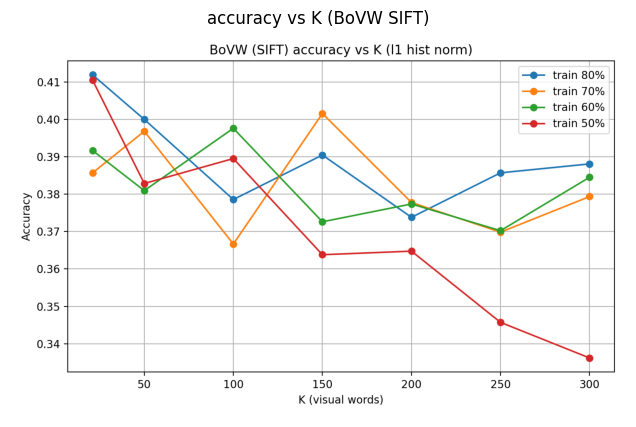

In [24]:
plot_path = os.path.join(RESULTS_DIR, "plots", "accuracy_vs_k.png")
if os.path.exists(plot_path):
    img = mpimg.imread(plot_path)
    plt.figure(figsize=(8,5))
    plt.imshow(img)
    plt.axis('off')
    plt.title("accuracy vs K (BoVW SIFT)")
    plt.show()
else:
    print("accuracy_vs_k.png not found!")

### **Confusion matrices**

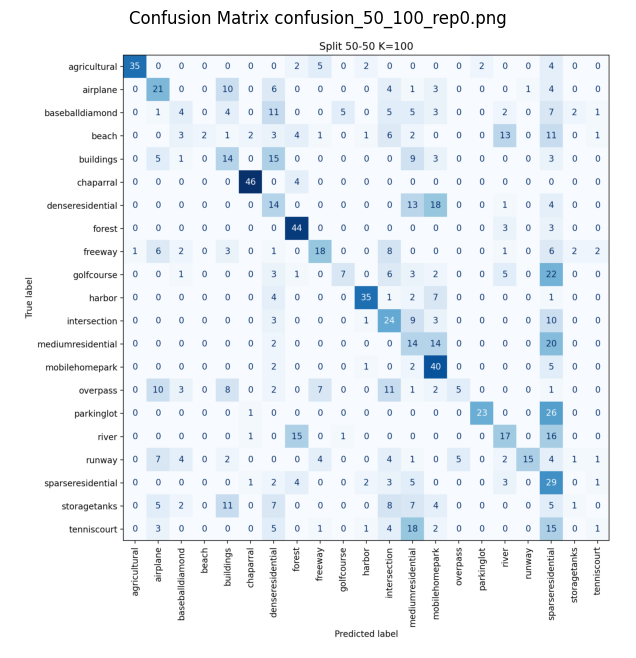

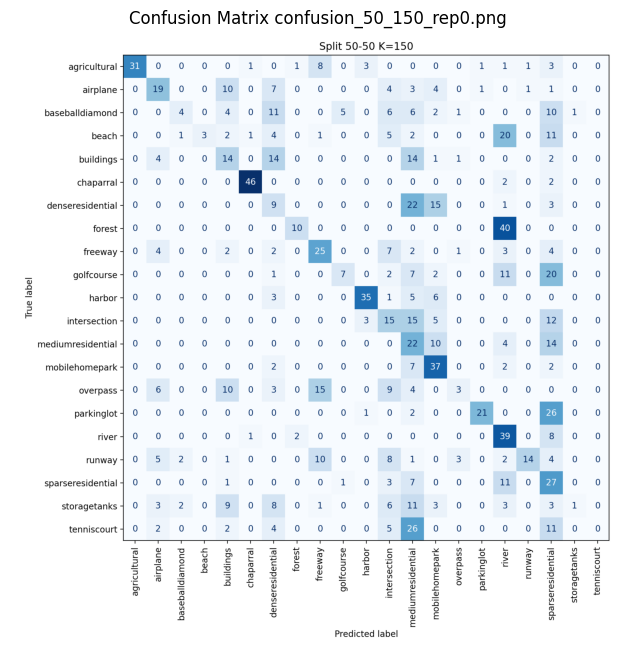

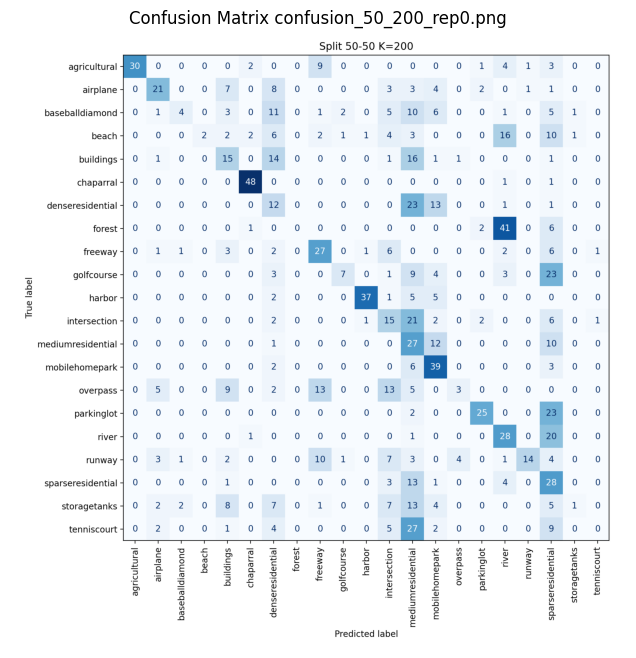

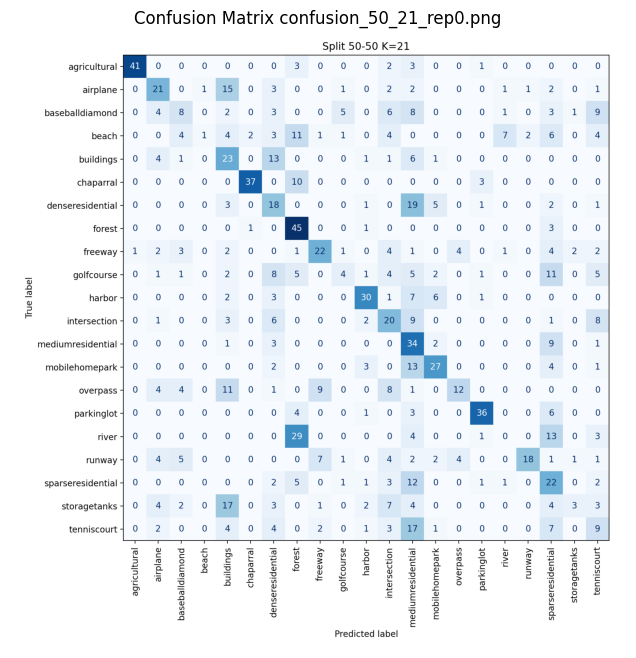

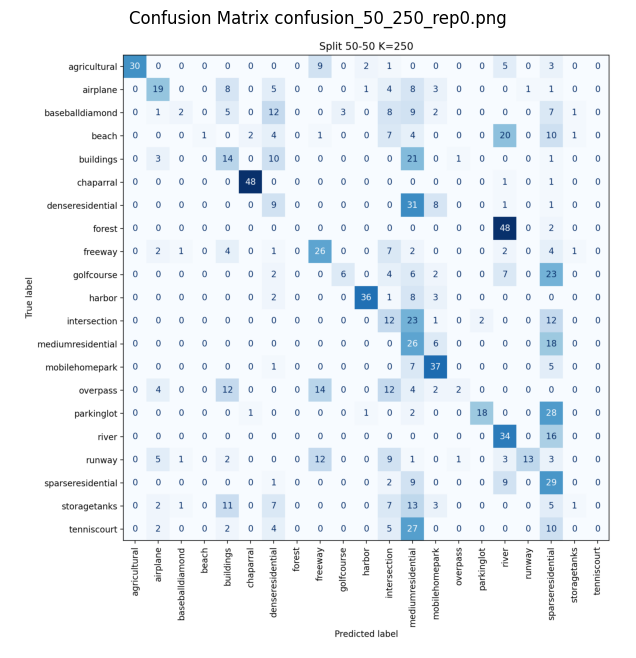

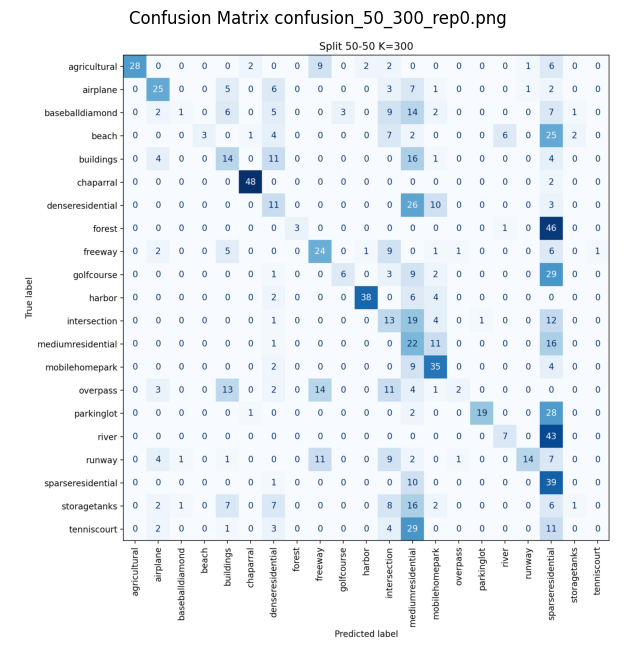

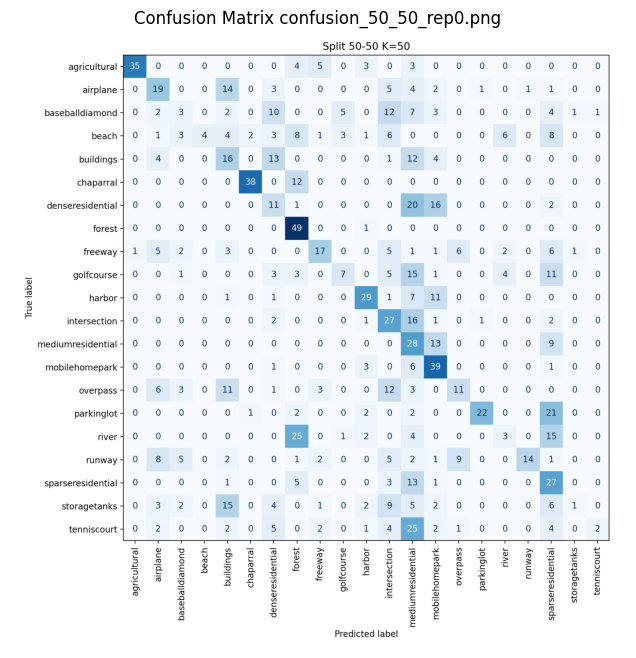

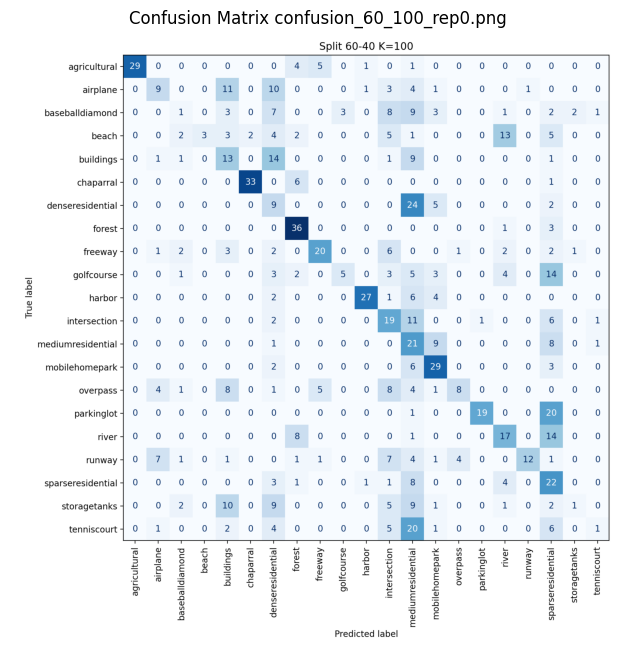

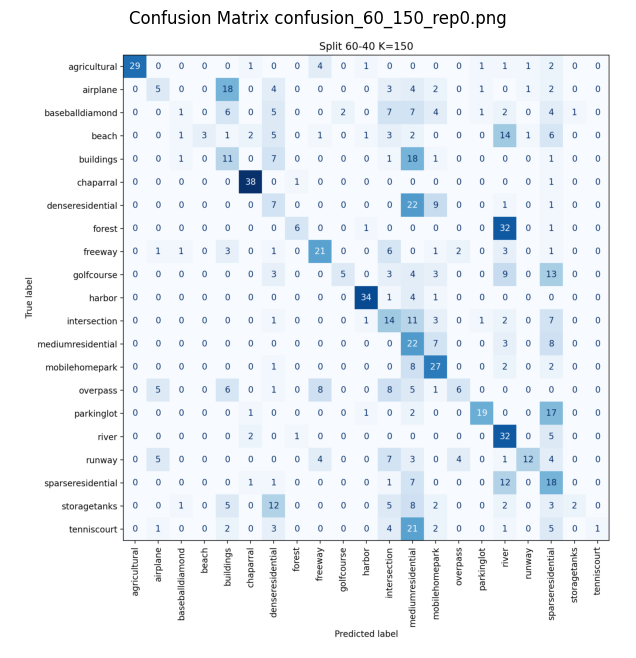

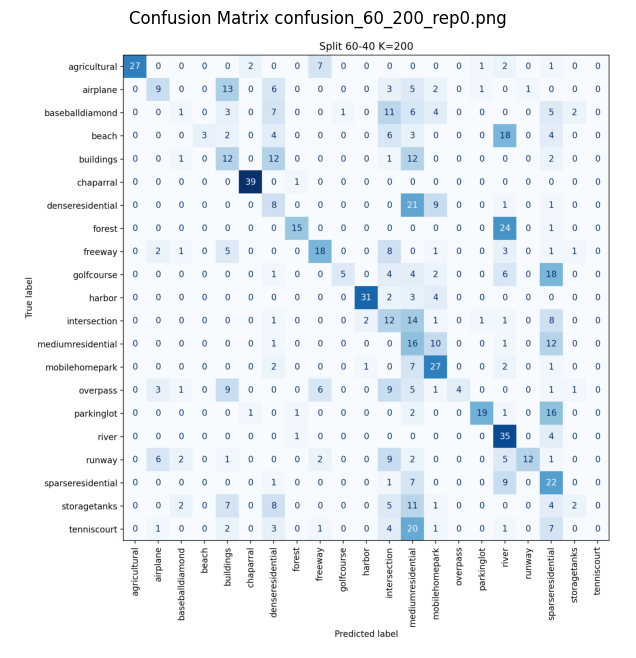

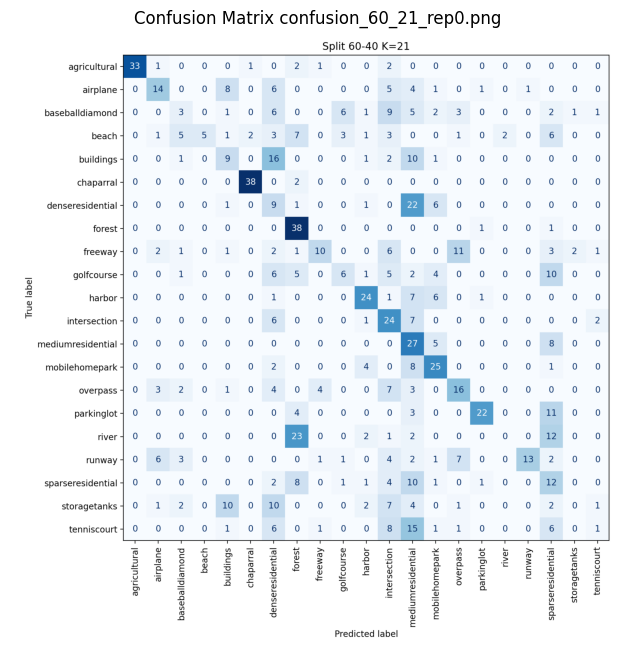

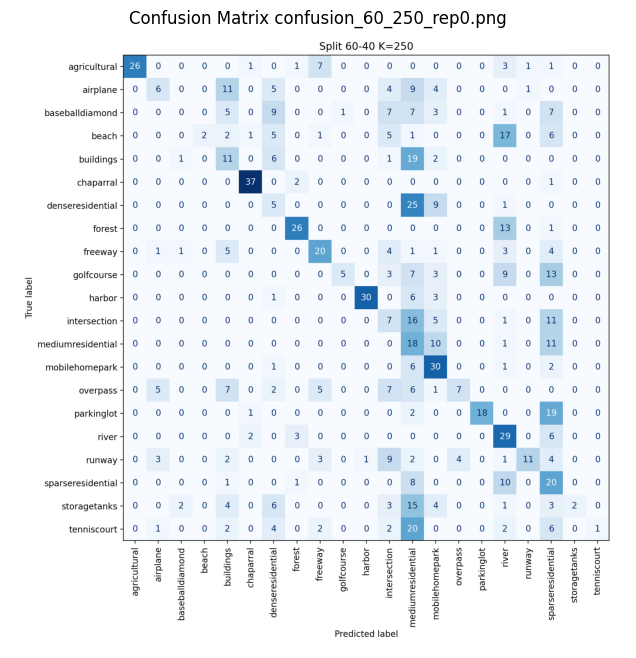

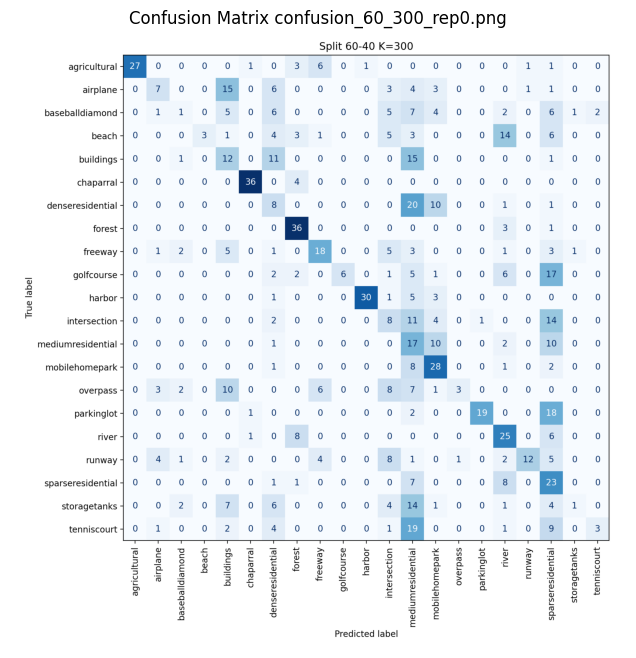

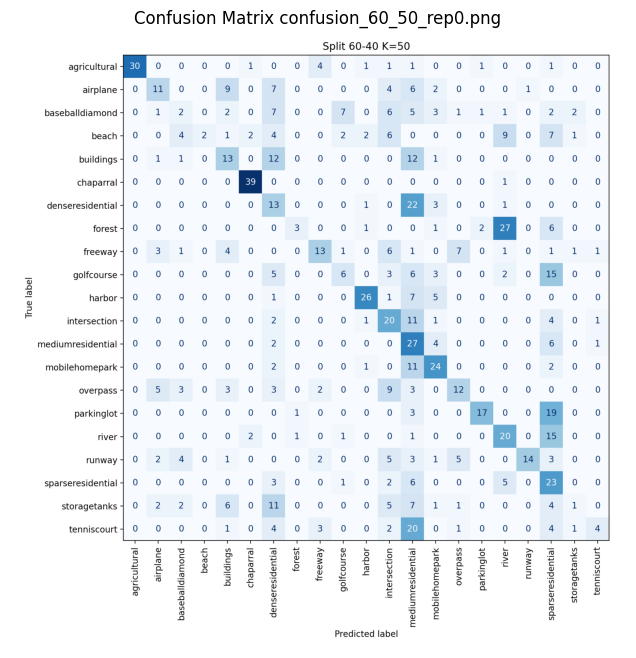

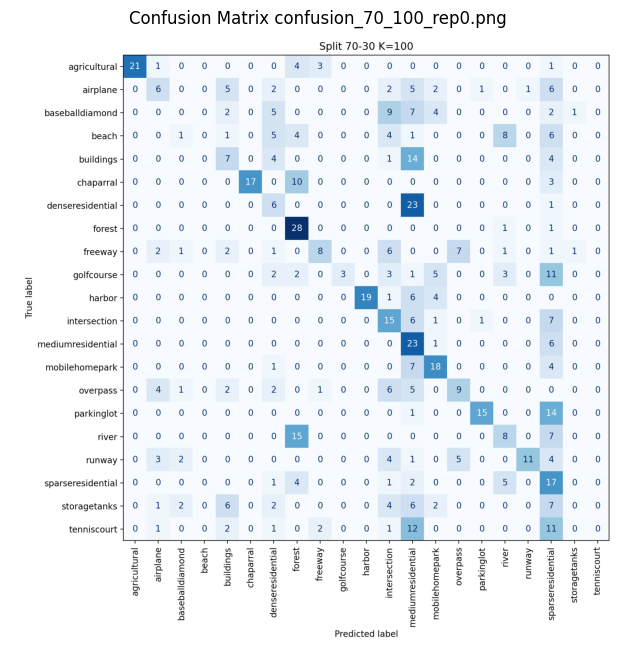

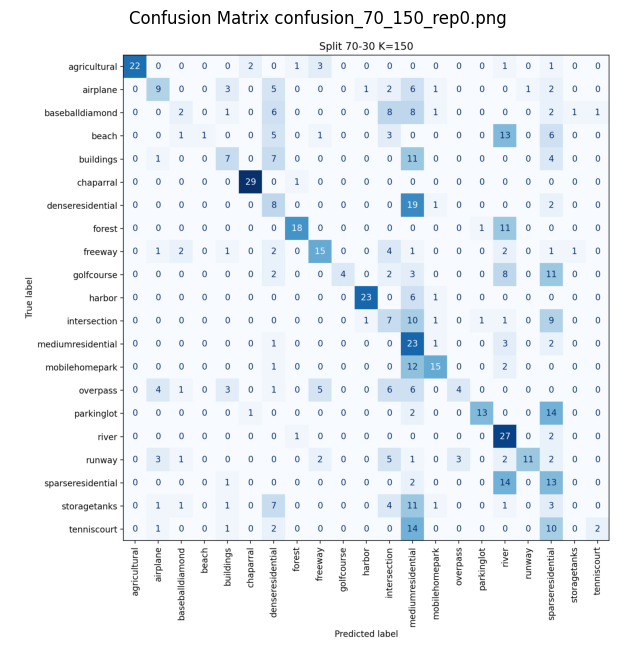

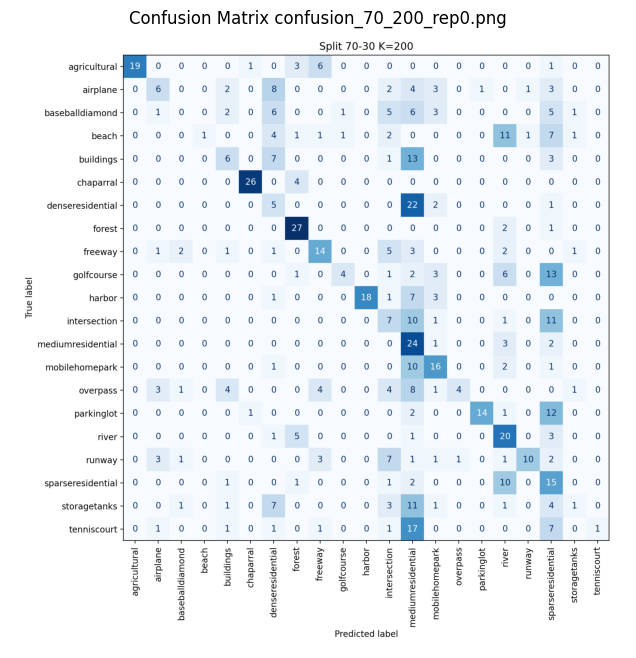

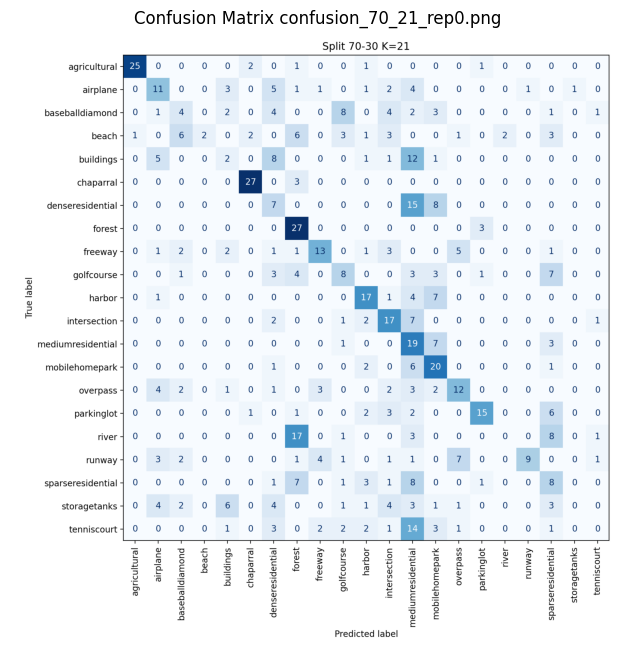

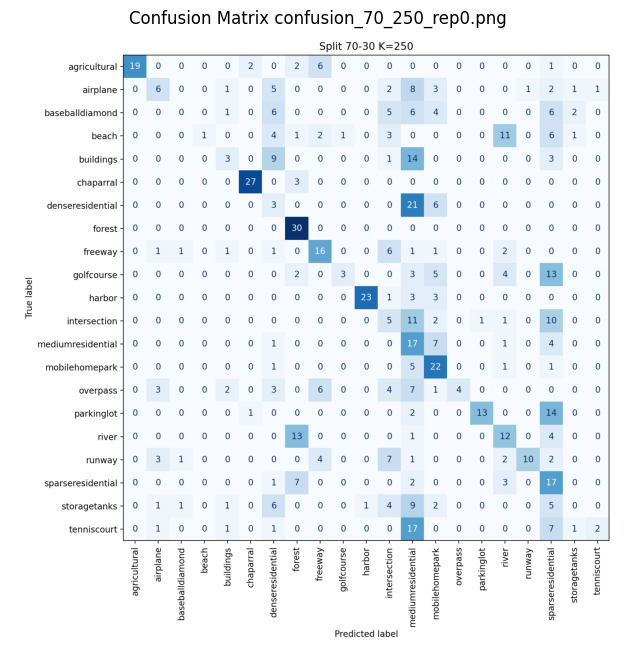

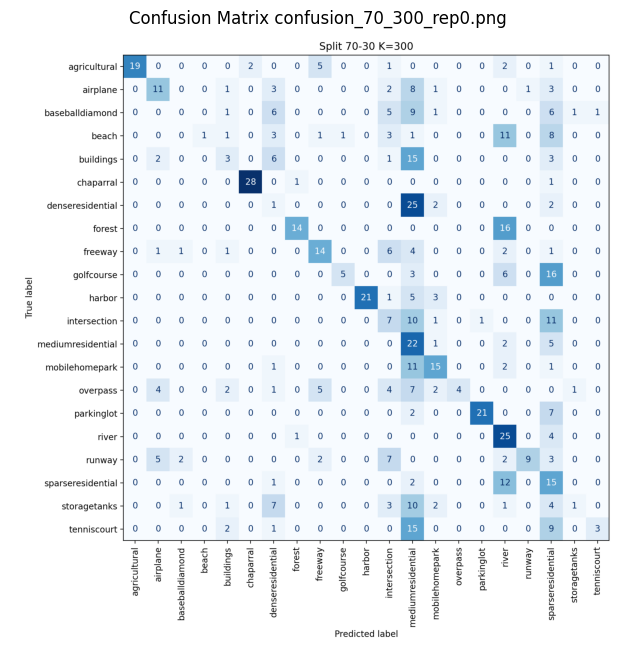

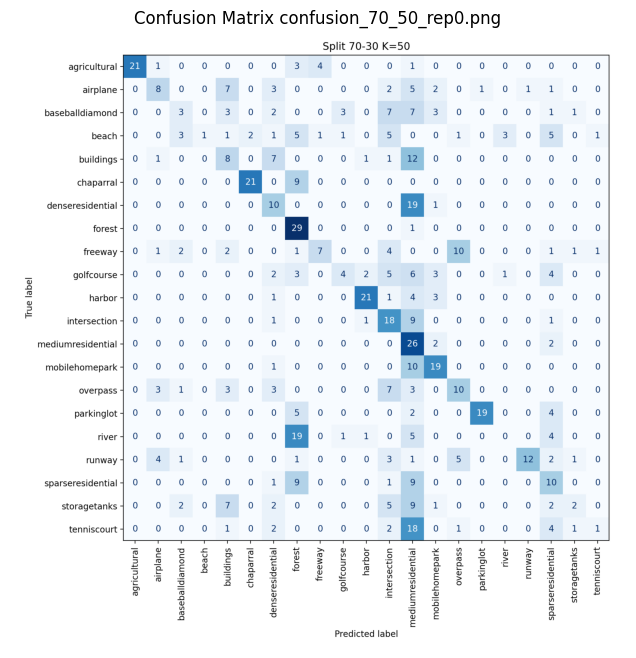

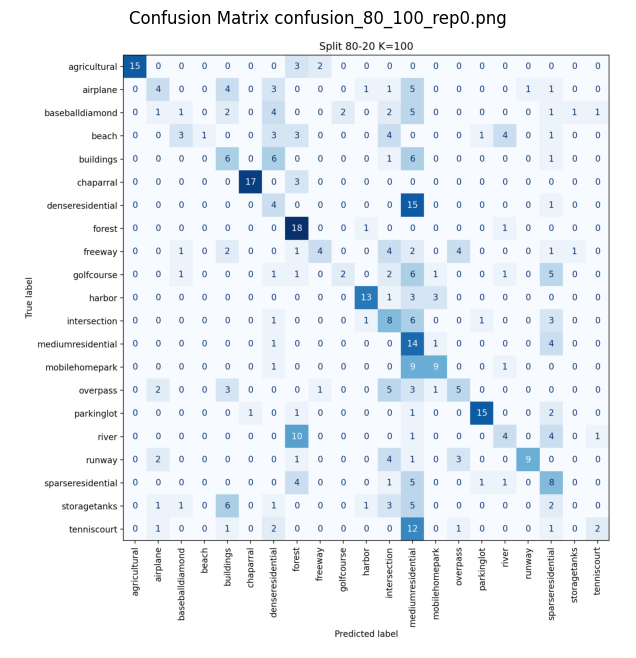

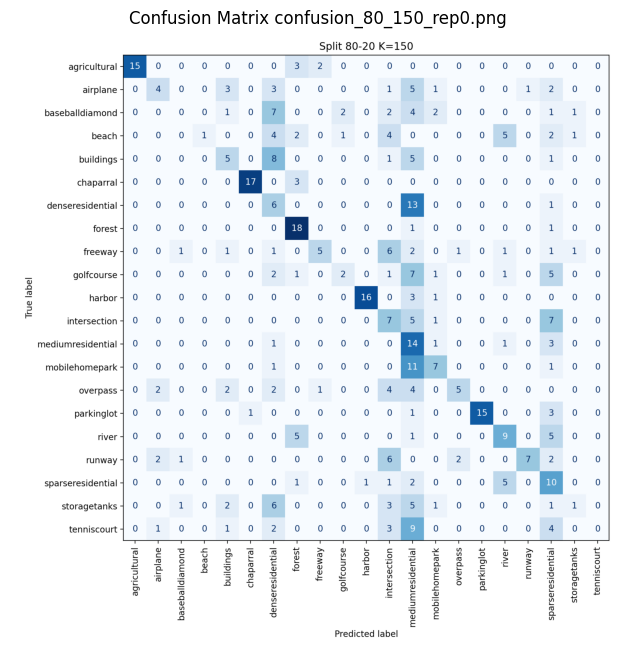

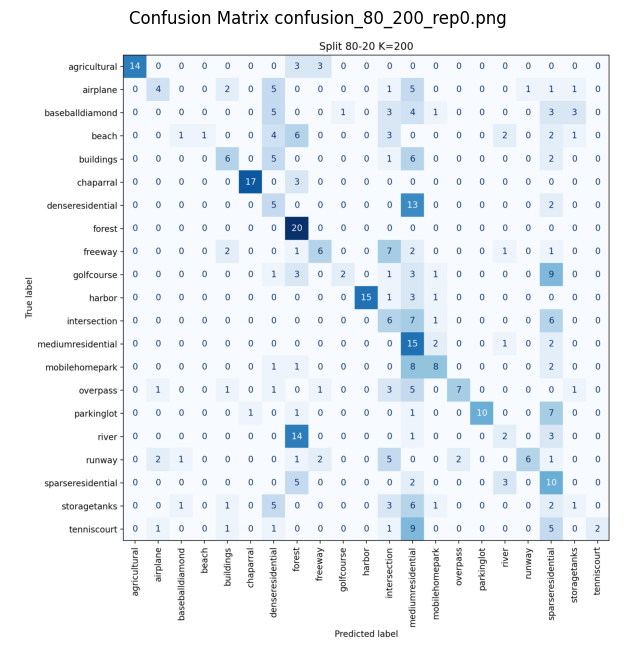

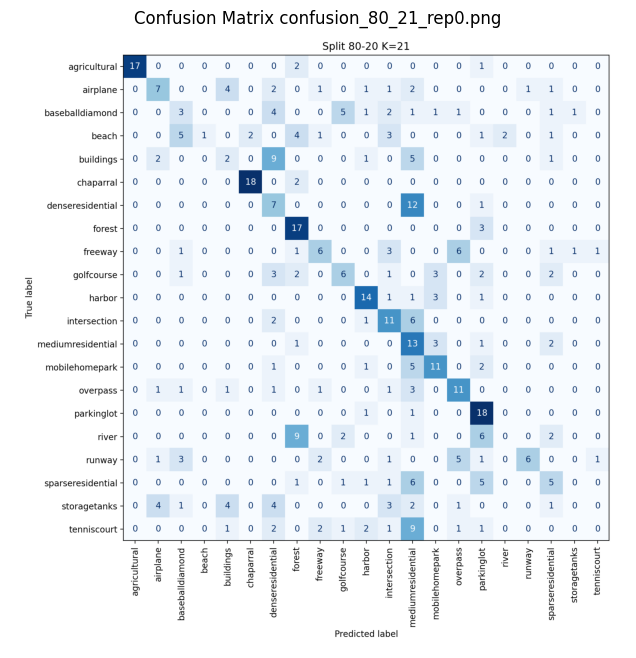

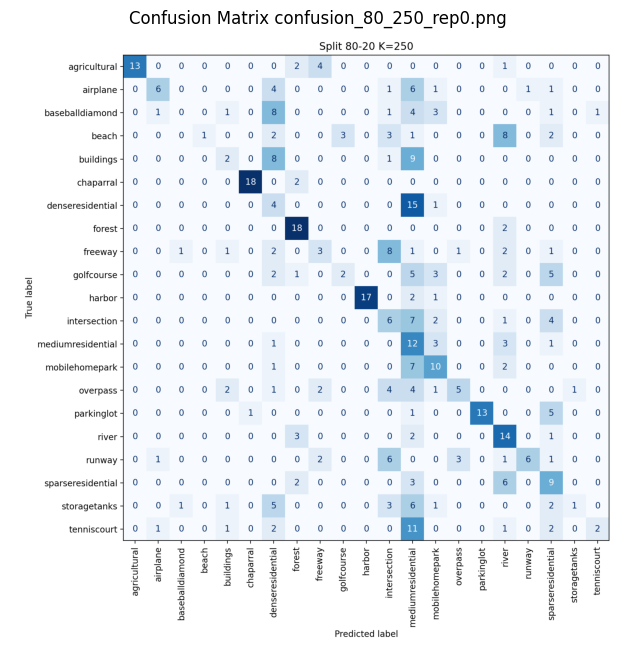

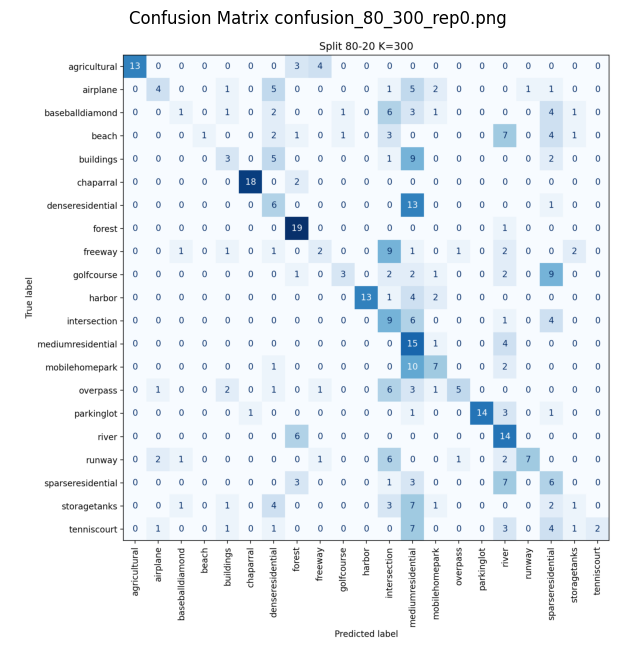

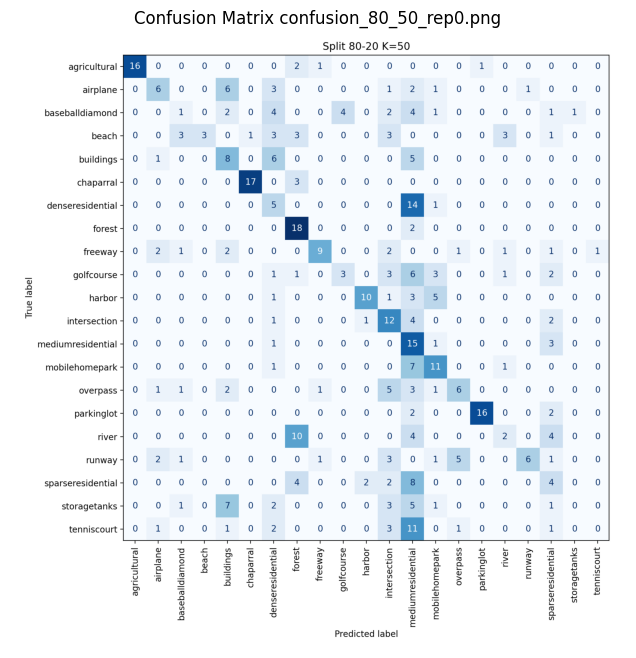

In [25]:
conf_dir = os.path.join(RESULTS_DIR, "confusion")
conf_paths = sorted(glob.glob(os.path.join(conf_dir, "confusion_*.png")))

if not conf_paths:
    print("No confusion matrix plots found.")
else:
    for i, conf_path in enumerate(conf_paths):
        img = mpimg.imread(conf_path)
        plt.figure(figsize=(8,8))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Confusion Matrix {os.path.basename(conf_path)}")
        plt.show()

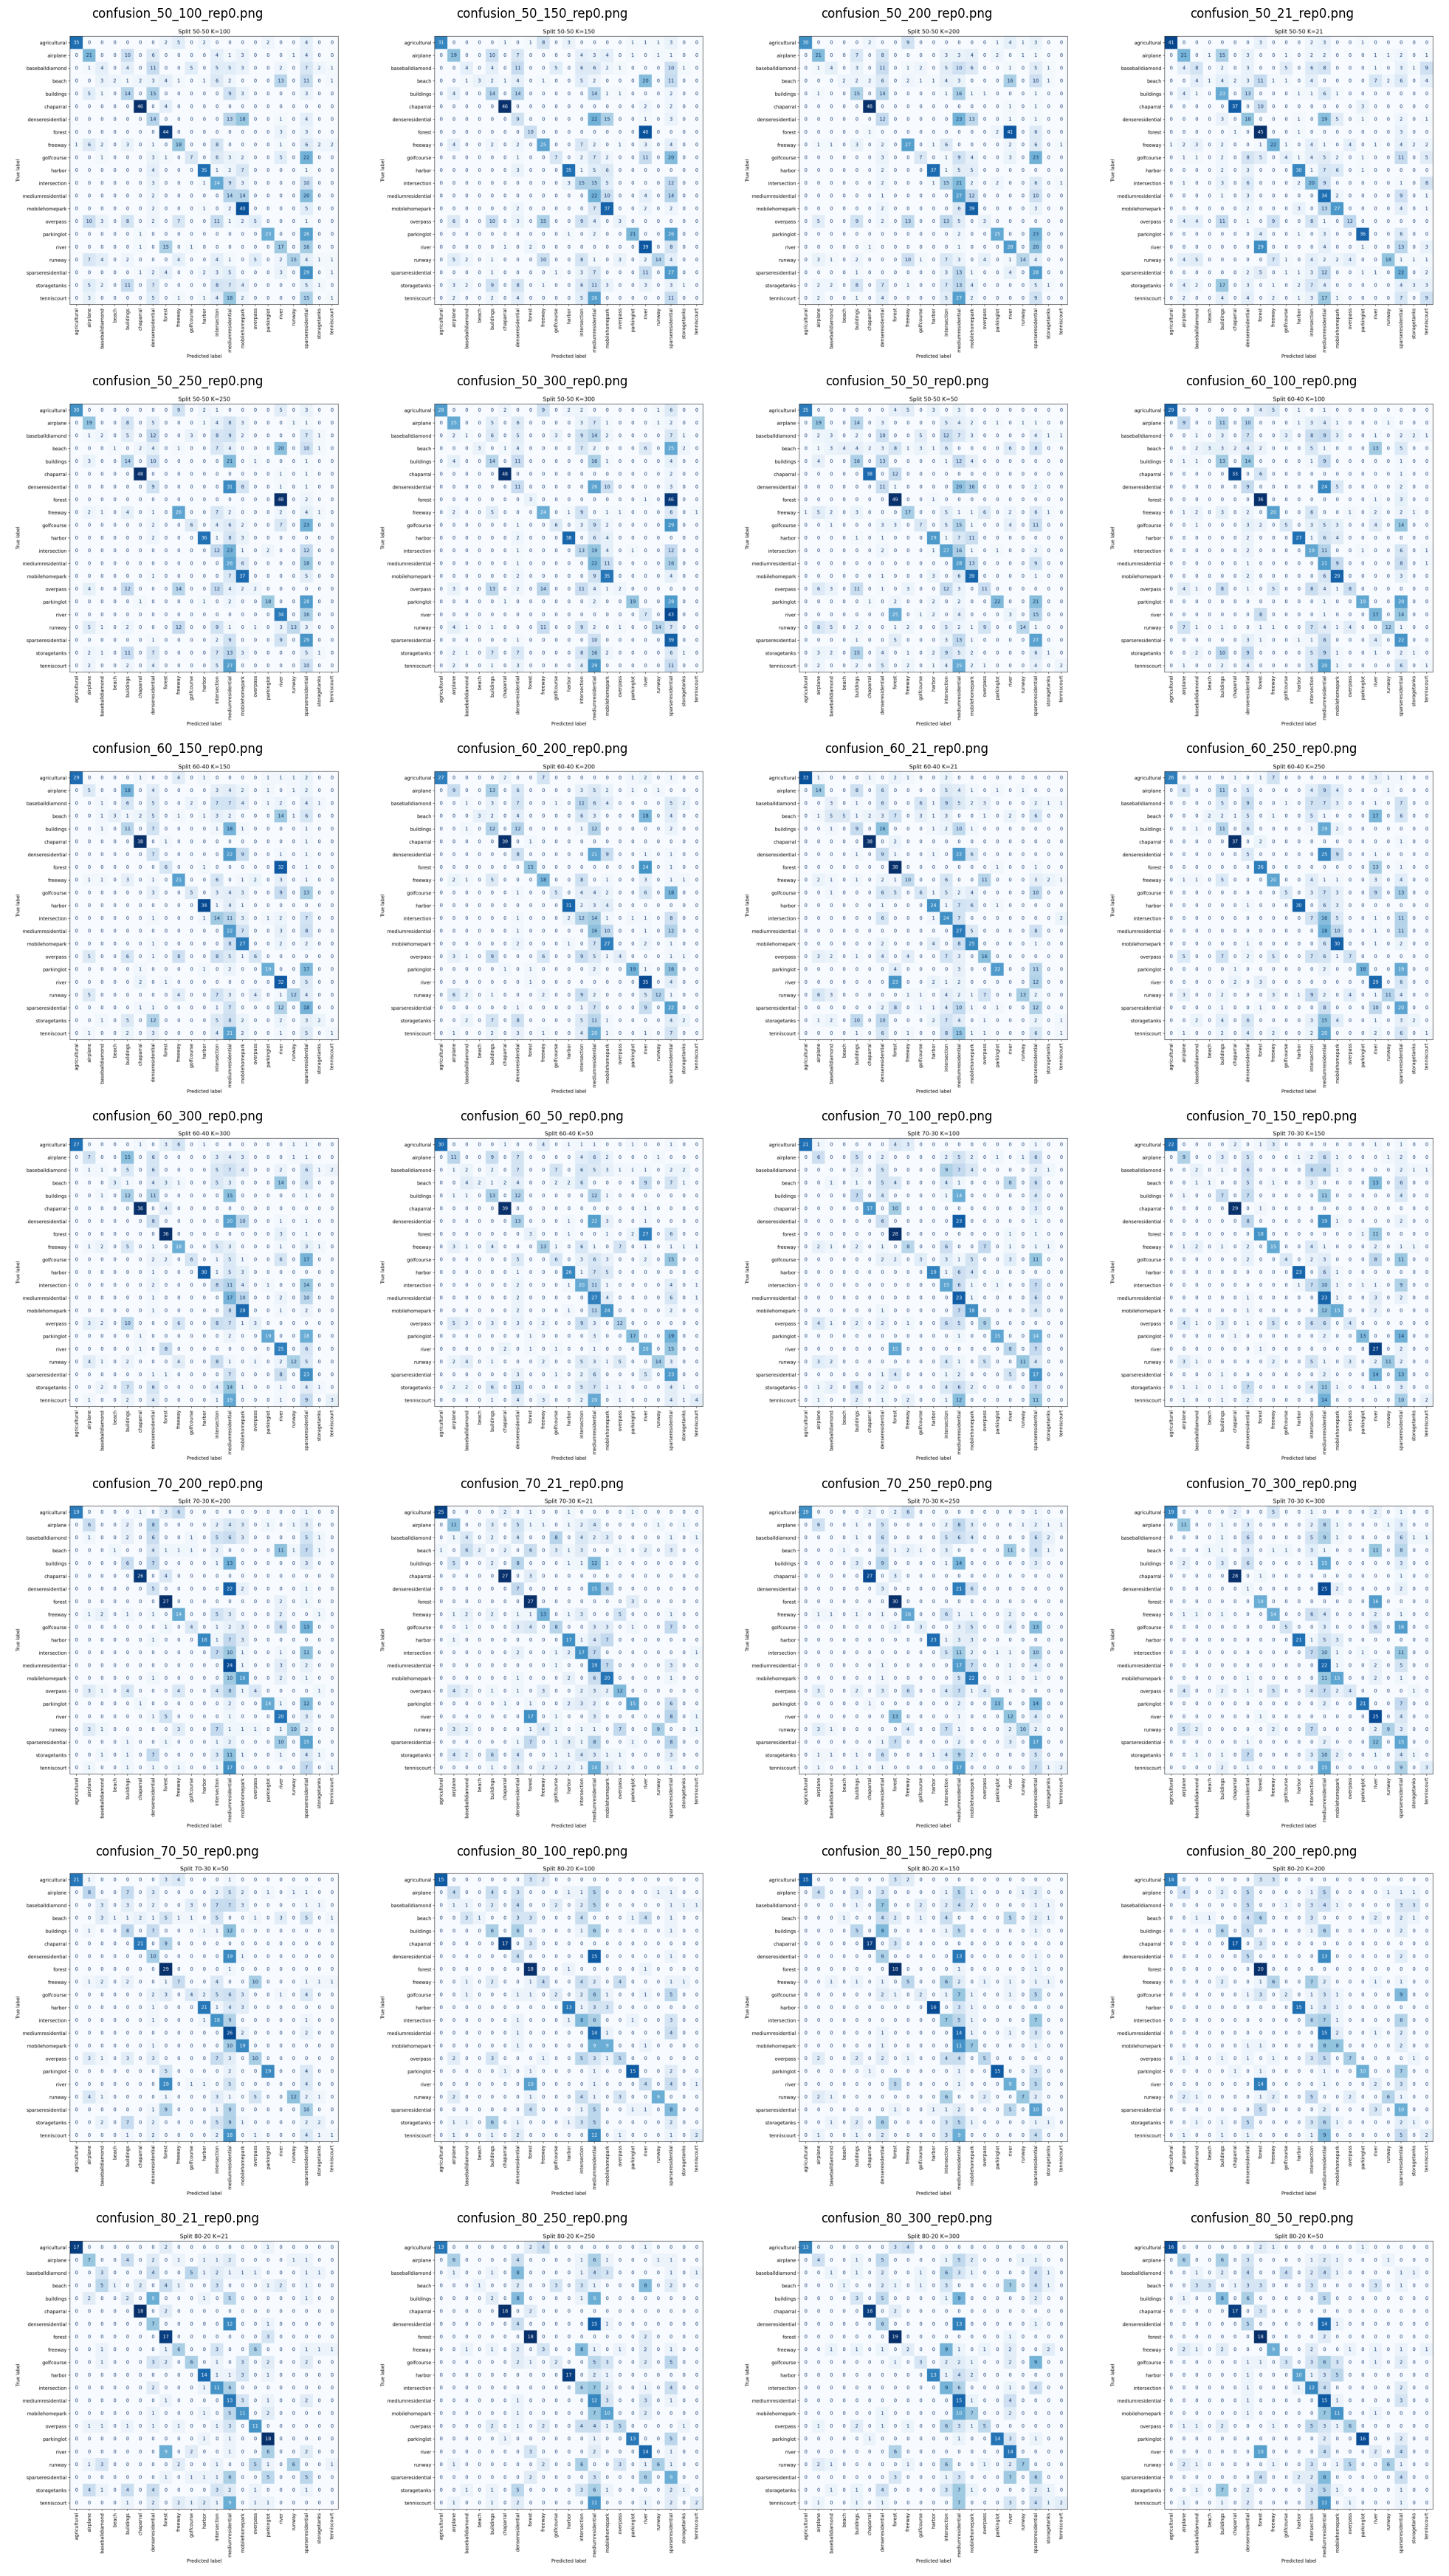

In [27]:
n = len(conf_paths)
cols = 4
rows = math.ceil(n / cols)
plt.figure(figsize=(5*cols, 5*rows))
for i, path in enumerate(conf_paths):
    img = mpimg.imread(path)
    plt.subplot(rows, cols, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(os.path.basename(path))
plt.tight_layout()
plt.show()